# Processing of the statistics gathered during the runs on the cluster

In [1]:
import glob
import pandas as pd
%matplotlib inline

In [2]:
date = r'20180612'
path = r'../../results/' + date + r'/'
allFiles = glob.glob(path + "*.csv")
allStatsSizeCSV = r'allStatsSize.csv'
allStatsTimeCSV = r'allStatsTime.csv'
df = pd.DataFrame()
list_ = []
for file_ in allFiles:
    if str(file_) != (path + allStatsSizeCSV) and str(file_) != (path + allStatsTimeCSV):
        df = pd.read_csv(file_, index_col=None, header=0)
        columns = df.columns.tolist()
        cols_to_use = columns[:len(columns) - 1] # drop the last one
        df = df[cols_to_use]
        list_.append(df)
df = pd.concat(list_)
df['inputFileName'] = df['inputFileName'].str.slice(len('/data/datasets/'))

In [3]:
allStats = df[['inputFileName', 'summaryType', 'allTriplesSummarizationTime', 'outputGraphSize']].sort_values(['summaryType', 'inputFileName'])
allStatsSize = allStats.pivot(index='inputFileName', columns='summaryType', values='outputGraphSize')
allStatsTime = allStats.pivot(index='inputFileName', columns='summaryType', values='allTriplesSummarizationTime')
allStatsSize.to_csv(path + allStatsSizeCSV)
allStatsTime.to_csv(path + allStatsTimeCSV)

In [4]:
allStatsSize

summaryType,1fb,2ps,2pts,2ptw,2pw,s,ts,tw,w
inputFileName,,,,,,,,,
bsbm/bsbm100m.nt,37805.0,13429.0,40270.0,40270.0,13390.0,NaN,40270.0,40270.0,13390.0
bsbm/bsbm10m.nt,11424.0,4101.0,14813.0,14813.0,4066.0,4102.0,14813.0,14813.0,4066.0
bsbm/bsbm1m.nt,4731.0,1067.0,3054.0,3054.0,1046.0,1067.0,3054.0,3054.0,1046.0
dblp/dblp_large.nt,8899.0,95.0,221.0,221.0,45.0,NaN,NaN,221.0,45.0
dbpedia/dbpedia_persondata_en.nt,1817.0,23.0,12.0,12.0,10.0,21.0,12.0,12.0,10.0
insee/insee_geo.nt,632.0,752.0,799.0,798.0,738.0,752.0,799.0,798.0,738.0
lubm/lubm100m.nt,243.0,72.0,143.0,143.0,38.0,72.0,143.0,143.0,38.0
lubm/lubm10m.nt,239.0,72.0,143.0,143.0,38.0,72.0,143.0,143.0,38.0
lubm/lubm1m.nt,263.0,71.0,143.0,143.0,38.0,71.0,143.0,143.0,38.0


In [5]:
allStatsTime

summaryType,1fb,2ps,2pts,2ptw,2pw,s,ts,tw,w
inputFileName,,,,,,,,,
bsbm/bsbm100m.nt,497692.0,970332.0,472035.0,592017.0,790534.0,NaN,1034640.0,301496.0,236978.0
bsbm/bsbm10m.nt,29673.0,52572.0,32332.0,31737.0,50990.0,93919.0,70789.0,18161.0,15806.0
bsbm/bsbm1m.nt,2015.0,3931.0,2719.0,2672.0,3527.0,5533.0,3826.0,1472.0,1526.0
dblp/dblp_large.nt,732510.0,1239023.0,725430.0,778551.0,1017881.0,NaN,NaN,310543.0,395891.0
dbpedia/dbpedia_persondata_en.nt,22223.0,47263.0,40216.0,36195.0,38954.0,74735.0,70001.0,16784.0,15612.0
insee/insee_geo.nt,1002.0,1779.0,1241.0,1337.0,1695.0,2651.0,1640.0,803.0,890.0
lubm/lubm100m.nt,381256.0,803106.0,432424.0,526164.0,729283.0,1344895.0,815644.0,298137.0,255159.0
lubm/lubm10m.nt,25152.0,46669.0,32313.0,31892.0,38854.0,66923.0,50130.0,24090.0,16787.0
lubm/lubm1m.nt,2144.0,3591.0,2807.0,2799.0,3138.0,5416.0,3663.0,1968.0,1678.0


In [6]:
def number(summaryType):
    if summaryType == 'w':
        return 0.1
    elif summaryType == 's':
        return 0.2
    elif summaryType == 'tw':
        return 0.3
    elif summaryType == 'ts':
        return 0.4
    elif summaryType == '2pw':
        return 0.5
    elif summaryType == '2ps':
        return 0.6
    elif summaryType == '2ptw':
        return 0.7
    elif summaryType == '2pts':
        return 0.8
    elif summaryType == '1fb':
        return 0.9
    return 0

df['color'] = df.apply(lambda row: number(row['summaryType']), axis=1)

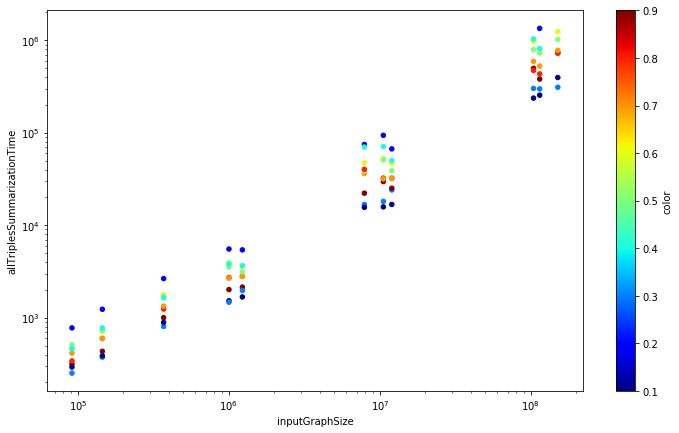

In [7]:
df[['allTriplesSummarizationTime', 'inputGraphSize', 'summaryType', 'inputFileName', 'color']].plot.scatter(x='inputGraphSize', logx=True, y='allTriplesSummarizationTime', logy=True, c='color', colormap='jet', figsize=(12, 7), sharex=False)

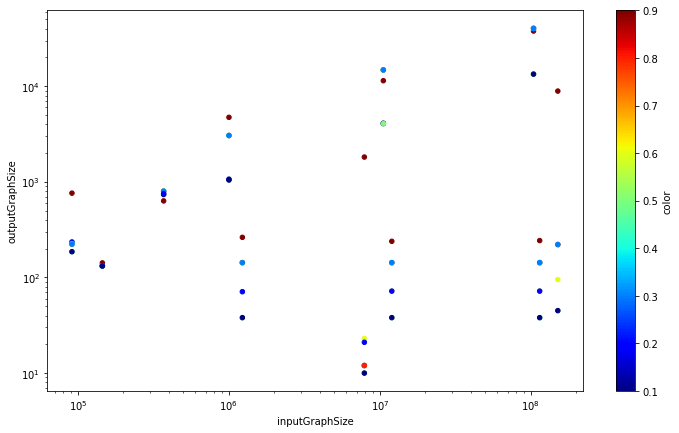

In [8]:
df[['outputGraphSize', 'inputGraphSize', 'summaryType', 'inputFileName', 'color']].plot.scatter(x='inputGraphSize', logx=True, y='outputGraphSize', logy=True, c='color', colormap='jet', figsize=(12, 7), sharex=False)